**AI disclosure:** no generative AI was used at any point for the contents of this file.<br>
This Jupyter Notebook was produced by Luna Sarrazin (thomas.sarrazin@mail.utoronto.ca), 
with suggestions and review by Ömer Can Caner (omer.caner@mail.utoronto.ca).

In [1]:
import numpy as np
import PIL
from PIL import Image
import matplotlib.pyplot as plt

Reading image data

In [2]:
def img_to_arr(filename, mode):
    """
    Return a NumPy array of the file with the specified filename in the specified mode (light/dark).
    """
    img = Image.open(f'{mode}/{filename}')
    arr = np.array(img) # read as 480 lines of 752 pixels
    return arr

light_imgs = []
dark_imgs = []

# read data from light frames
with open("light/images.txt") as f:
    
    # create array of image filenames without newline character
    filenames = f.read().splitlines() 
    
    for i in range(0, 30):
        light_frame = img_to_arr(filenames[i], "light")
        light_imgs.append(light_frame) # add frame to temp list

    # stack temp list into 3D arrays
    light_arr = np.stack(light_imgs, axis=-1)

# repeat with dark frames
with open("dark/images.txt") as f:
    
    filenames = f.read().splitlines() 
    
    for i in range(0, 30):
        dark_frame = img_to_arr(filenames[i], "dark")
        dark_imgs.append(dark_frame)
        
    dark_arr = np.stack(dark_imgs, axis=-1)

Now, we can start doing some data manipulation! We'll calculate a mean per pixel per mode (light/dark) over the 30 frames collected for each mode, and subtract the dark average for that pixel from that pixel's value on each light frame.

In [3]:
dark_avg_3d = []

for i in range(0, 30):
    dark_avg_3d.append(np.mean(dark_arr, axis=2))

dark_avg = np.stack(dark_avg_3d, axis=-1)

diff = light_arr - dark_avg

We can now calculate the mean and variance of `diff` per pixel and plot them! Since we're working with 360960 pixels, it's more convenient to take a subsample for a more readable scatter plot. We decided to take a subsample of 1000 values. To keep results consistent throughout simulations, we make a NumPy random Generator and set its seed to 0 (line 6).

Text(0, 0.5, 'Variance (ADU²)')

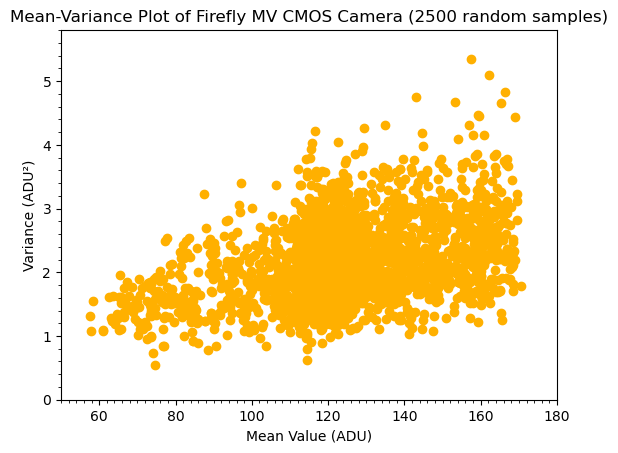

In [26]:
diff_avg = (np.mean(diff, axis=-1)).flatten()
diff_var = (np.var(diff, axis=-1)).flatten()

# choose 1000 random samples from the average and variance (making sure they're from the same pixel!) 
rand_ct = 2500
rand_generator = np.random.default_rng(seed=0)

rand_arr = np.arange(0, 360960, 1)
subspl_arr = rand_generator.choice(rand_arr, size=rand_ct)

sub_diff_avg = []
sub_diff_var = []

for subspl in subspl_arr:
    sub_diff_avg.append(diff_avg[subspl])
    sub_diff_var.append(diff_var[subspl])

subspl_arr_avg = np.array(sub_diff_avg)
subspl_arr_var = np.array(sub_diff_var)

# plot the photon-transfer curve 
fig, ax = plt.subplots(1)
ax.scatter(subspl_arr_avg, subspl_arr_var, color="#FFB000")

ax.set_xticks(np.arange(50, 181, 2), minor=True)
ax.set_xticks(np.arange(60, 181, 20))

ax.set_yticks(np.arange(0, 6, 0.2), minor=True)
ax.set_yticks(np.arange(0, 6, 1))

ax.set_title("Mean-Variance Plot of Firefly MV CMOS Camera (2500 random samples)")
ax.set_xlabel("Mean Value (ADU)")
ax.set_ylabel("Variance (ADU²)")

Now, we can have a look at plotting a linear regression curve, which will give us the gain and noise of the sensor! We will do so using an in-house least squares method.

Gain: 87.23482514688551 e/ADU; Noise: 0.7278010786068635 ADU


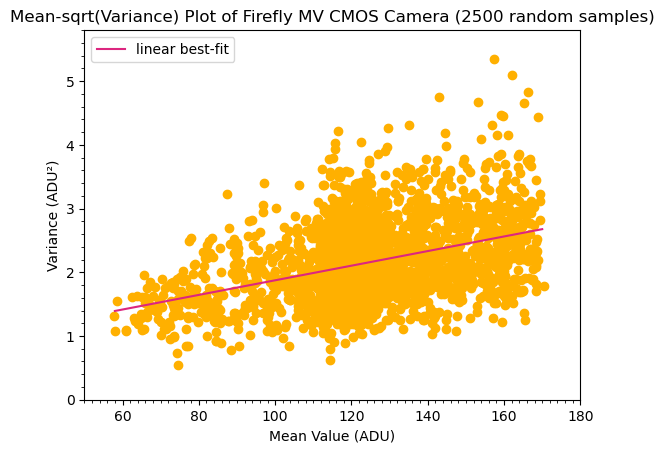

In [27]:
def least_squares(x_arr, y_arr, N):
    """
    Return a tuple of gradient (m) and constant (c) for linear regression using values from arrays x_arr and y_arr.
    Both arrays contain N entries.
    """    
    x_arr2 = x_arr ** 2
    xy_arr = x_arr * y_arr
    
    sum_x = np.sum(x_arr)
    sum_y = np.sum(y_arr)
    sum_x2 = np.sum(x_arr2)
    sum_xy = np.sum(xy_arr)
    
    det = (N * sum_x2 - sum_x ** 2)**(-1)

    m = det * (sum_xy * N - sum_y * sum_x)
    c = det * (sum_y * sum_x2 - sum_xy * sum_x)

    return (m, c)

fig, ax = plt.subplots(1)
ax.scatter(subspl_arr_avg, subspl_arr_var, color="#FFB000")

m, c = least_squares(subspl_arr_avg, subspl_arr_var, rand_ct)
adu_range = np.arange(round(min(sub_diff_avg)), round(max(sub_diff_avg)), 1) # using round min/max avoids extrapolation
ax.plot(adu_range, m * adu_range + c, color="#DC267F", label="linear best-fit")

""
ax.set_xticks(np.arange(50, 181, 2), minor=True)
ax.set_xticks(np.arange(60, 181, 20))

ax.set_yticks(np.arange(0, 6, 0.2), minor=True)
ax.set_yticks(np.arange(0, 6, 1))

ax.set_title("Mean-sqrt(Variance) Plot of Firefly MV CMOS Camera (2500 random samples)")
ax.set_xlabel("Mean Value (ADU)")
ax.set_ylabel("Variance (ADU²)")
ax.legend(loc="upper left")

print(f'Gain: {1/m} e/ADU; Noise: {c} ADU')

As a summary, we can observe that the variance of pixel values increases linearly with the values themselves, with a slope of approximately 238.8 e/ADU and an intercept circa 0.924 ADU.

While this best-fit line is not extrapolated on the figure above, the non-zero intercept shows that there is still some variance even when the signal is equal to 0 ADU. The reason for this is that there is still read noise from the camera, which becomes the dominant detection at low ADUs.

When the mean pixel value increases, the variance increases too. However, this relation is less than unitary, meaning that variance grows at a slower rate than mean value. In the case of our sensor, the variance only increases by approximately 1\% of the increase in mean value.<br>
This means that the variance becomes a significantly lower fraction of the mean value as the latter increases. In other words, the camera detections go from read noise-dominated to photon noise-dominated.

The slope of the graph is called the **Gain** of the sensor, in other words the number of electrons that the sensor needs to detect for an increase in 1 ADU. With our value for gain above, we would need slightly over 89 electrons for an increase in 1 ADU.

In [16]:
# TODO: change the values above and plot depending on Piazza response!
"""
It is important to note that taking random sub-samples of the full data will affect the slope and intercept slightly. When running the simulation on all pixels (while chronophage to compute!), we obtain the following:<br>
`Gain: 0.0112 e/ADU` (3 s.f.)<br>
`Noise: 0.766 ADU` (3 s.f.)<br>
Showing that a sub-sample of 1000 typically resembles the value for the entire sample set for this experiment.
"""

'\nIt is important to note that taking random sub-samples of the full data will affect the slope and intercept slightly. When running the simulation on all pixels (while chronophage to compute!), we obtain the following:<br>\n`Gain: 0.0112 e/ADU` (3 s.f.)<br>\n`Noise: 0.766 ADU` (3 s.f.)<br>\nShowing that a sub-sample of 1000 typically resembles the value for the entire sample set for this experiment.\n'